## MNIST LeNet

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import time

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
cm = 1/2.54  # centimeters to inches

import nninfo

N_WORKERS=12


### Train network

In [3]:
# Set experiment id
experiment_id = "mnist_lenet"

#### Set up parameters and train first network

In [4]:
# Note that we do not set initial seeds manually here, but save all seeds to the
# checkpoints files during training for later reproducibility. Rerunning this script
# will produce slightly different figures due to the randomness of network
# initialization etc.

layer_infos = [
    nninfo.LayerInfo(connection_layer='input', activation_function='input'),

    nninfo.LayerInfo(connection_layer='conv2d', connection_layer_kwargs={'in_channels': 1, 'out_channels': 6, 'kernel_size': 5, 'stride': 1, 'padding': (2, 2)}, activation_function='sigmoid'),
    nninfo.LayerInfo(connection_layer='avgpool2d', connection_layer_kwargs={'kernel_size': 2, 'stride': 2}, activation_function=None),

    nninfo.LayerInfo(connection_layer='conv2d', connection_layer_kwargs={'in_channels': 6, 'out_channels': 16, 'kernel_size': 5, 'stride': 1, 'padding': (0, 0)}, activation_function='sigmoid'),
    nninfo.LayerInfo(connection_layer='avgpool2d', connection_layer_kwargs={'kernel_size': 2, 'stride': 2}, activation_function=None),

    nninfo.LayerInfo(connection_layer='flatten', activation_function=None),

    nninfo.LayerInfo(connection_layer='linear', connection_layer_kwargs={'in_features': 5*5*16, 'out_features': 120}, activation_function='sigmoid'),
    nninfo.LayerInfo(connection_layer='linear', connection_layer_kwargs={'in_features': 120, 'out_features': 84}, activation_function='sigmoid'),
    nninfo.LayerInfo(connection_layer='linear', connection_layer_kwargs={'in_features': 84, 'out_features': 10}, activation_function='softmax_output'),
]

# Set weight initialization
initializer_name = 'xavier'

# Create network instance
network = nninfo.NeuralNetwork(layer_infos=layer_infos, init_str=initializer_name)

# Set task instance
task = nninfo.TaskManager('mnist_2d_dat')
# Split dataset into MNIST training set, and MNIST+QMNIST test set
task['full_set'].train_test_val_sequential_split(60_000, 10_000, 0)

# Create quantizer list with stochastic quantization. The input layer is not quantized.
quantizer = ([None]
             + [{'levels': 8, 'rounding_point': 'stochastic'}] + [None]
             + [{'levels': 8, 'rounding_point': 'stochastic'}] + [None]
             + [None]
             + [{'levels': 8, 'rounding_point': 'stochastic'}]
             + [{'levels': 8, 'rounding_point': 'stochastic'}]
             + [None]
            )

#Set up trainer
trainer = nninfo.Trainer(dataset_name='full_set/train',
                        optim_str='Adam',
                        loss_str='CELoss',
                        lr=0.01,
                        shuffle=True,
                        batch_size=64,
                        quantizer=quantizer)

# Set up tester
tester = nninfo.Tester(dataset_name='full_set/test')

# Set up schedule
schedule = nninfo.Schedule()
# Save training state for 50 logarithmically spaced checkpoints
schedule.create_log_spaced_chapters(100_000, 50)

# Combine components into experiment
experiment = nninfo.Experiment(experiment_id=experiment_id,
                        network=network,
                        task=task,
                        trainer=trainer,
                        tester=tester,
                        schedule=schedule)

# Run training for 10^5 epochs
experiment.run_following_schedule()

Starting training on run 0 starting at chapter 0, epoch 0
trained epoch: 1; train loss: 0.457213045741121; test loss: 1.4997493028640747
Finished training chapter 1.
trained epoch: 2; train loss: 0.07109490150734782; test loss: 1.484931230545044
Finished training chapter 2.
trained epoch: 3; train loss: 0.052155650866776704; test loss: 1.4812595844268799
Finished training chapter 3.
trained epoch: 4; train loss: 0.043908491259068254; test loss: 1.4806890487670898
Finished training chapter 4.
trained epoch: 5; train loss: 0.03501217346728469; test loss: 1.477799415588379
Finished training chapter 5.
trained epoch: 6; train loss: 0.03148963832228134; test loss: 1.479114294052124
Finished training chapter 6.
trained epoch: 7; train loss: 0.02640445630281853; test loss: 1.476366639137268
trained epoch: 8; train loss: 0.024672479929961265; test loss: 1.476580023765564
Finished training chapter 7.
trained epoch: 9; train loss: 0.021556874573323875; test loss: 1.4753825664520264
trained epoch

In [6]:
# Continue training

# Set up experiment
experiment = nninfo.Experiment.load(experiment_id)

experiment.continue_runs_following_schedule([0], 100)

nninfo.experiment: Continuing run 0 at chapter 16.


Starting training on run 0 starting at chapter 16, epoch 63
trained epoch: 64; train loss: 0.005559423562158834; test loss: 1.471929907798767
trained epoch: 65; train loss: 0.0036028401808031203; test loss: 1.4733165502548218
trained epoch: 66; train loss: 0.005561981805805605; test loss: 1.4709928035736084
trained epoch: 67; train loss: 0.0073410262177652005; test loss: 1.47110116481781
trained epoch: 68; train loss: 0.005399327698312966; test loss: 1.4715074300765991
trained epoch: 69; train loss: 0.0068024517256590625; test loss: 1.471937894821167
trained epoch: 70; train loss: 0.005394530399853795; test loss: 1.4722336530685425
trained epoch: 71; train loss: 0.005611884666138075; test loss: 1.4706525802612305
trained epoch: 72; train loss: 0.004219023081313276; test loss: 1.4717599153518677
trained epoch: 73; train loss: 0.005272086127434833; test loss: 1.4714860916137695
trained epoch: 74; train loss: 0.007891260709238979; test loss: 1.471876859664917
trained epoch: 75; train loss

#### Rerun training with different random weight initializations

In [ ]:
# Set up experiment
experiment = nninfo.Experiment.load(experiment_id)

# Compute 19 more training runs with different random weight initializations.
experiment.rerun(19)

### Evaluate network performance
#### Compute loss and accuracy

In [8]:
quantizer_params = ([None]
             + [{'levels': 8, 'rounding_point': 'stochastic'}] + [None]
             + [{'levels': 8, 'rounding_point': 'stochastic'}] + [None]
             + [None]
             + [{'levels': 8, 'rounding_point': 'stochastic'}]
             + [{'levels': 8, 'rounding_point': 'stochastic'}]
             + [None]
            )
experiment = nninfo.Experiment.load(experiment_id)
performance_measurement = nninfo.analysis.PerformanceMeasurement(experiment, ['full_set/train', 'full_set/test'], quantizer_params=quantizer_params)

performance_measurement.perform_measurements(run_ids=[0], chapter_ids=range(19), exists_ok=True)

Performing measurements for 19 checkpoints: [(0, 0), (0, 1), (0, 2), (0, 3), (0, 4), (0, 5), (0, 6), (0, 7), (0, 8), (0, 9), (0, 10), (0, 11), (0, 12), (0, 13), (0, 14), (0, 15), (0, 16), (0, 17), (0, 18)].
There is already a 'performance' result for run_id 0 and chapter_id 0. Skipping.
There is already a 'performance' result for run_id 0 and chapter_id 1. Skipping.
There is already a 'performance' result for run_id 0 and chapter_id 2. Skipping.
There is already a 'performance' result for run_id 0 and chapter_id 3. Skipping.
There is already a 'performance' result for run_id 0 and chapter_id 4. Skipping.
There is already a 'performance' result for run_id 0 and chapter_id 5. Skipping.
There is already a 'performance' result for run_id 0 and chapter_id 6. Skipping.
There is already a 'performance' result for run_id 0 and chapter_id 7. Skipping.
There is already a 'performance' result for run_id 0 and chapter_id 8. Skipping.
There is already a 'performance' result for run_id 0 and chapter

#### Plot loss and accuracy

Avg. Train Set accuracy at epoch 100: 0.9995333333333334 +- nan
Avg. Test Set accuracy at epoch 100: 0.9902 +- nan


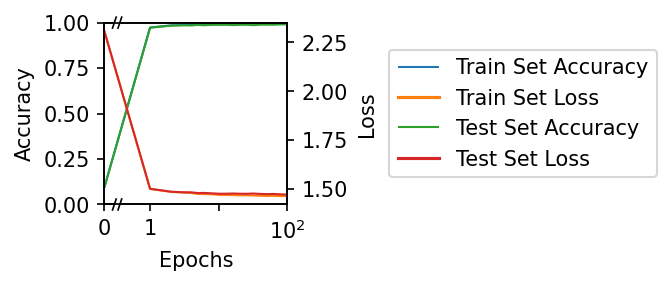

In [9]:
# Load performance file
experiment = nninfo.Experiment.load(experiment_id)
performance_measurement = nninfo.analysis.PerformanceMeasurement.load(experiment, "performance")

fig, ax = plt.subplots(figsize=(4*cm, 4*cm), dpi=150)
ax.set_ylim(0, 1)
twinax = ax.twinx()

# Plot accuracy
nninfo.plot.plot_loss_accuracy(performance_measurement.results, ax, twinax)

ax.legend(ncol=1, bbox_to_anchor=(1.5, 0.5), loc='center left');

In [ ]:
# Save result
plt.savefig(f"experiments/exp_{experiment_id}/plots/performance.pdf", bbox_inches='tight')

In [16]:
import nninfo.config
nninfo.config.N_WORKERS = 3
print(nninfo.config.N_WORKERS)

import numpy as np
np.__config__.show()
import os
os.environ['OPENBLAS_NUM_THREADS'] = '1'

3
blas_info:
    libraries = ['cblas', 'blas', 'cblas', 'blas']
    library_dirs = ['/Users/david/mambaforge/envs/nninfo/lib']
    include_dirs = ['/Users/david/mambaforge/envs/nninfo/include']
    language = c
    define_macros = [('HAVE_CBLAS', None)]
blas_opt_info:
    define_macros = [('NO_ATLAS_INFO', 1), ('HAVE_CBLAS', None)]
    libraries = ['cblas', 'blas', 'cblas', 'blas']
    library_dirs = ['/Users/david/mambaforge/envs/nninfo/lib']
    include_dirs = ['/Users/david/mambaforge/envs/nninfo/include']
    language = c
lapack_info:
    libraries = ['lapack', 'blas', 'lapack', 'blas']
    library_dirs = ['/Users/david/mambaforge/envs/nninfo/lib']
    language = f77
lapack_opt_info:
    libraries = ['lapack', 'blas', 'lapack', 'blas', 'cblas', 'blas', 'cblas', 'blas']
    library_dirs = ['/Users/david/mambaforge/envs/nninfo/lib']
    language = c
    define_macros = [('NO_ATLAS_INFO', 1), ('HAVE_CBLAS', None)]
    include_dirs = ['/Users/david/mambaforge/envs/nninfo/include']
Supp

### Perform quintivariate PID on hidden layers $L_3$, $L_4$ and $L_5$

In [17]:
# Load experiment
experiment = nninfo.Experiment.load(experiment_id)

layer = 6
target = [nninfo.NeuronID('Y', (1,))]
sources = [[nninfo.NeuronID(f'L{layer}', (i+1,))] for i in range(400)]

# Create quantizer list for deterministic rounding.
quantization_dict = ([None]
            + [{'levels': 8, 'rounding_point': 'stochastic'}] + [None]
            + [{'levels': 8, 'rounding_point': 'stochastic'}] + [None]
            + [None]
            + [{'levels': 8, 'rounding_point': 'stochastic'}]
            + [{'levels': 8, 'rounding_point': 'stochastic'}]
            + [None]
        )

measurement = nninfo.analysis.PIDMeasurement(experiment=experiment,
                                                measurement_id=f'summary_measurement_L{layer}',
                                                dataset_name='full_set/train',
                                                quantizer_params=quantization_dict,
                                                pid_definition='deg_red',
                                                binning_kwargs={'binning_method' : 'none'},
                                                target_id_list=target,
                                                source_id_lists=sources)

itic = time.time_ns()
measurement.perform_measurements(run_ids=[0], chapter_ids=[0], exists_ok=True)
itoc = time.time_ns()

print(f"Computing DEG_RED for L{layer} took: ", (itoc-itic)/10**9, "s")

Performing measurements for 1 checkpoints: [(0, 0)].
Performing 'pid' measurement for run_id 0 and chapter_id 0.
Computing degree of redundancy
Total MI: 3.319870926755277
Source 0 MI: 0.0025811662447290757
Source 1 MI: 0.012342729619316222
Source 2 MI: 0.010618926307105736
Source 3 MI: 0.008005716607848403
Source 4 MI: 0.0018183506194227102
Source 5 MI: 0.005115660172506466
Source 6 MI: 0.008987702394426266
Source 7 MI: 0.01851253129818371
Source 8 MI: 0.015010475114990731
Source 9 MI: 0.004661592176805291
Source 10 MI: 0.009553337349170526
Source 11 MI: 0.012992288305997067
Source 12 MI: 0.014418156311070303
Source 13 MI: 0.004678248633720538
Source 14 MI: 0.0028891342635338057
Source 15 MI: 0.011966216295367873
Source 16 MI: 0.015800330284640986
Source 17 MI: 0.025410274422100376
Source 18 MI: 0.009864281162321705
Source 19 MI: 0.0024774350262767994
Source 20 MI: 0.011118876206080444
Source 21 MI: 0.010888169169448188
Source 22 MI: 0.010356747704463027
Source 23 MI: 0.01040623529651

ValueError: All arrays must be of the same length

In [7]:
# Merge results files
import pandas as pd

layer = 4

df_r0_9 = pd.read_hdf(f'../experiments/exp_mnist_large/pid_targetpointwise_L{layer}/results_r0-9.h5')
print(len(df_r0_9))
df_r10_19 = pd.read_hdf(f'../experiments/exp_mnist_large/pid_targetpointwise_L{layer}/results_r10-19.h5')
print(len(df_r10_19))

df = pd.concat([df_r0_9, df_r10_19], axis=0)

# Convert tuple of int to int
df['target'] = df['target'].apply(lambda x: x[0] if isinstance(x, tuple) else x)

print(len(df))

df.to_hdf(f'../experiments/exp_mnist_large/pid_targetpointwise_L{layer}/results.h5', key='results', mode='w')
del df

3900
3900
7800


### Compute representational complexity and plot results

In [ ]:
from nninfo.postprocessing.pid_postprocessing import get_pid_summary_quantities

cm = 1/2.54
fig, ax= plt.subplots(figsize=(5*cm, 4*cm), dpi=150)
inset_axis = inset_axes(ax, width=0.7, height=0.4)

# Load experiment
experiment = nninfo.experiment.Experiment.load(experiment_id)

# Plot accuracy on inset axis
performance_measurement = nninfo.analysis.PerformanceMeasurement.load(experiment, 'performance')
nninfo.plot.plot_accuracy(performance_measurement.results, 'full_set/train', inset_axis, c='k', label='Train')
nninfo.plot.plot_accuracy(performance_measurement.results, 'full_set/test', inset_axis, c='k', ls='--', label='Test')
inset_axis.set_ylim(0, 1)
inset_axis.set_ylabel('Acc.')
inset_axis.legend(bbox_to_anchor=(1.1, 1.3), loc='upper left')
    
for layer in [3, 4, 5]:
    measurement_loaded = nninfo.analysis.PIDMeasurement.load(experiment=experiment, measurement_id=f'pid_L{layer}')
    pid_summary = get_pid_summary_quantities(measurement_loaded.results)
    nninfo.plot.plot_representational_complexity(pid_summary, ax, label=f'Layer {layer}')

ax.yaxis.set_minor_locator(ticker.MultipleLocator(0.25))

ax.set_xlabel('Training Epoch')
ax.set_ylabel(r'Repr. Compl. $C$')

ax.legend(bbox_to_anchor=(1, .6), loc='upper left')

ax.set_ylim(1, 4)
ax.set_yticks([1, 2, 3])
ax.set_yticklabels(['1', '2', '3']);

In [ ]:
# Save results
plt.savefig(f"experiments/exp_{experiment_id}/plots/representational_complexity.pdf", bbox_inches='tight')

### Compute Reing Directed Differences (doi:10.3390/e23010079) for layers $L_3$, $L_4$ and $L_5$

In [ ]:
# Load experiment
experiment = nninfo.Experiment.load(experiment_id)

for layer in [3, 4, 5]:

    target = [nninfo.NeuronID('Y', (1,))]
    source1 = [nninfo.NeuronID(f'L{layer}', (1,))]
    source2 = [nninfo.NeuronID(f'L{layer}', (2,))]
    source3 = [nninfo.NeuronID(f'L{layer}', (3,))]
    source4 = [nninfo.NeuronID(f'L{layer}', (4,))]
    source5 = [nninfo.NeuronID(f'L{layer}', (5,))]

    # Create quantizer list for deterministic rounding.
    quantization_dict = [None] + 5 * [{'levels': 8, 'rounding_point': 'center_saturating'}] + [None]

    measurement = nninfo.analysis.PIDMeasurement(experiment=experiment,
                                                 measurement_id=f'reing_directed_differences_L{layer}',
                                                 dataset_name='full_set/train',
                                                 quantizer_params=quantization_dict,
                                                 pid_definition='reing',
                                                 binning_kwargs={'binning_method' : 'none'},
                                                 target_id_list=target,
                                                 source_id_lists=[source1, source2, source3, source4, source5])

    itic = time.time_ns()
    measurement.perform_measurements(run_ids='all', chapter_ids='all', exists_ok=True)
    itoc = time.time_ns()

    print(f"Computing Reing Directed Differences for L{layer} took: ", (itoc-itic)/10**9, "s")

In [ ]:
from nninfo.postprocessing.reing_postprocessing import get_directed_reing_complexity

cm = 1/2.54
fig, ax= plt.subplots(figsize=(5*cm, 4*cm), dpi=150)
inset_axis = inset_axes(ax, width=0.7, height=0.4)

# Load experiment
experiment = nninfo.experiment.Experiment.load(experiment_id)

# Plot accuracy on inset axis
performance_measurement = nninfo.analysis.PerformanceMeasurement.load(experiment, 'performance')
nninfo.plot.plot_accuracy(performance_measurement.results, 'full_set/train', inset_axis, c='k', label='Train')
nninfo.plot.plot_accuracy(performance_measurement.results, 'full_set/test', inset_axis, c='k', ls='--', label='Test')
inset_axis.set_ylim(0, 1)
inset_axis.set_ylabel('Acc.')
inset_axis.legend(bbox_to_anchor=(1.1, 1.3), loc='upper left')


    
for layer in [3, 4, 5]:
    reing_measurement = nninfo.analysis.PIDMeasurement.load(experiment=experiment, measurement_id=f'reing_directed_differences_L{layer}')
    reing_complexity = get_directed_reing_complexity(reing_measurement.results)
    nninfo.plot.plot_reing_complexity(reing_complexity, ax, label=f'Layer {layer}')

ax.yaxis.set_minor_locator(ticker.MultipleLocator(0.25))

ax.set_xlabel('Training Epoch')
ax.set_ylabel(r'Reing Repr. Compl. $C_R$')

ax.legend(bbox_to_anchor=(1, .6), loc='upper left')

ax.set_ylim(1, 4)
ax.set_yticks([1, 2, 3])
ax.set_yticklabels(['1', '2', '3']);

In [ ]:
plt.savefig(f"experiments/exp_{experiment_id}/plots/reing_complexity.pdf", bbox_inches='tight')